# Fuel flow analysis

The dataset contains 100 simulated flights. Sensors recorded four things during each flight:

| Signal | What it means | Unit |
| --- | --- | --- |
| fuel flow | fuel burned per hour | pounds per hour |
| altitude | aircraft height | feet |
| speed | aircraft speed | km/h |
| wind | wind speed | knots |

**Key finding:** fuel flow follows one simple rule.

- Fly **twice as fast**, burn **twice** the fuel.
- Fly **twice as high**, burn **a quarter** of the fuel.
- Wind makes **no difference**.

$$\text{fuel} \approx C \times \frac{\text{speed}}{\text{altitude}^2}$$

A linear regression on log scales finds this rule; a more complex model is not needed.

Code: `cleanup.py` (Q1), `compute.py` (regressions), `plot.py` (figures).

## Q1: Cleaning the data

In [1]:
import numpy as np
import pandas as pd

import cleanup
import compute
import plot

raw = cleanup.load()
pd.DataFrame(
    {s: {"shape": df.shape, "dtypes": df.dtypes.unique().tolist()} for s, df in raw.items()}
).T

,shape,dtypes
fuel_flow,"(40, 100)",[object]
altitude,"(40, 100)",[object]
speed,"(40, 100)",[object]
wind,"(40, 100)",[object]


Each file is a table: one column per flight, one row per moment in time. Short flights have
empty cells at the end.

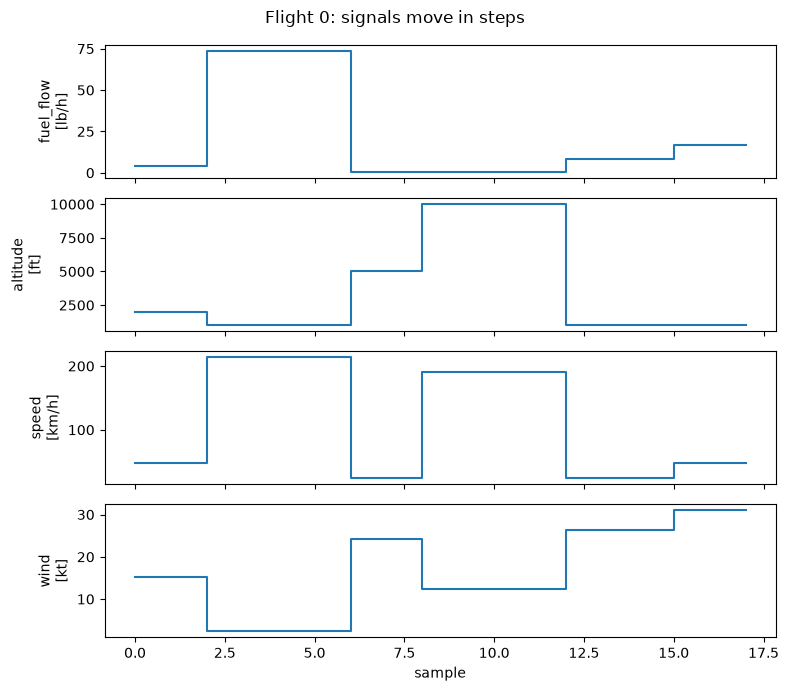

In [2]:
plot.flight_signals(raw, flight=0);

Flight 0 shows that the signals move in **steps**: the aircraft holds one speed and altitude for
a while, then changes to the next. Each step is one data point for the model.

In [3]:
long = cleanup.to_long(raw)
padding = long[cleanup.SIGNALS].isna().all(axis=1)
partial = long[~padding & long[cleanup.SIGNALS].isna().any(axis=1)]
print(f"{len(long)} rows, {padding.sum()} NaN padding, {len(partial)} partially NaN:")
partial

4000 rows, 1893 NaN padding, 2 partially NaN:


,t,flight,fuel_flow,altitude,speed,wind
2012,20,12,17063779.44,NaN,NaN,NaN
2112,21,12,17063779.44,NaN,NaN,NaN


In [4]:
samples = long.dropna()
for s in ["altitude", "speed"]:
    print(s, samples[s].value_counts().sort_index().to_dict(), "\n")
samples[cleanup.SIGNALS].describe().round(2)

altitude {-50.0: 1, 1000.0: 218, 2000.0: 227, 3000.0: 232, 4000.0: 198, 5000.0: 254, 6000.0: 196, 7000.0: 185, 8000.0: 199, 9000.0: 153, 10000.0: 218, 50095.0: 12, 50855.0: 3, 50950.0: 7, 70000.0: 1, 72000.0: 1} 

speed {-3963.0: 1, -6.0: 1, 23.75: 209, 47.5: 190, 71.25: 189, 95.0: 244, 118.75: 206, 142.5: 187, 166.25: 184, 190.0: 255, 213.75: 226, 223.75: 2, 237.5: 194, 247.5: 4, 271.25: 3, 318.75: 5, 342.5: 4, 375000.0: 1} 



,fuel_flow,altitude,speed,wind
count,2105.00,2105.00,2105.00,2105.00
mean,144318.73,5844.33,309.46,16.84
std,1557495.41,5768.48,8171.37,9.75
min,-634931.33,-50.00,-3963.00,0.33
25%,0.71,3000.00,71.25,8.00
50%,1.66,5000.00,142.50,16.33
75%,5.48,8000.00,190.00,25.33
max,39683208.00,72000.00,375000.00,33.33


Altitudes and speeds follow a fixed grid: 1000, 2000, ... 10 000 ft and 23.75, 47.5, ... 237.5
km/h. Values outside this grid are errors, of two kinds:

- **Spikes**: single impossible readings, such as a speed of 375 000 km/h or a negative
  altitude.
- **Faulty flights**: one sensor wrong for the whole flight, shown below.

In [5]:
(
    samples[samples.flight.isin(cleanup.BROKEN_FLIGHTS)]
    .drop_duplicates(["flight", *cleanup.SIGNALS])
    .set_index(["flight", "t"])
)

fuel_flow  altitude   speed       wind
flight t                                            
7      0   5.070823e-01   10000.0  342.50  28.333333
12     0   1.027795e+07    2000.0  213.75  31.666667
44     0   8.161090e+00   50095.0   23.75  25.333333
7      2   7.814306e-01    8000.0  342.50  12.333333
       4   2.010988e-01    9000.0  247.50  10.000000
12     4   1.027795e+07   10000.0  118.75  15.333333
44     4   2.073448e+00   50095.0   23.75  32.333333
12     7   1.630980e+07    6000.0   23.75  12.666667
44     7   7.344981e+01   50855.0  213.75   1.333333
7      8   8.127915e+00    1000.0  223.75   8.333333
       10  1.050201e+01    2000.0  318.75   4.333333
12     10  1.027795e+07    8000.0   23.75  27.666667
44     10  3.294294e-01   50095.0   23.75  28.333333
7      15  2.709305e+00    3000.0  271.25  21.666667
12     15  1.706378e+07    7000.0   23.75  17.000000
44     15  8.244028e+01   50950.0  237.50  10.333333
       17  1.272578e+00   50950.0  237.50  32.666667
12     18  1.706378e+07    6000.0  166.25  21.000000

- **Flight 7**: speed reads about 200 km/h too high throughout (sensor offset).
- **Flight 12**: fuel reads about 10 million. Every other flight is under 100.
- **Flight 44**: altitude reads about 50 000 ft, far above all other flights, while its fuel
  flow matches low altitudes.

These 3 flights are removed. Spikes are removed one reading at a time; the rest of each flight
is kept.

In [6]:
kept = samples[~samples.flight.isin(cleanup.BROKEN_FLIGHTS)]
spikes = kept[~cleanup.in_range(kept)]
print(f"removed {len(spikes)} spike samples:")
spikes

removed 7 spike samples:


,t,flight,fuel_flow,altitude,speed,wind
104,1,4,-6.349313e+05,-50.0,213.75,23.333333
105,1,5,3.748793e+00,3000.0,375000.00,2.000000
124,1,24,3.968321e+07,7000.0,-6.00,14.333333
130,1,30,1.242825e+01,70000.0,142.50,24.000000
413,4,13,4.026072e-01,9000.0,-3963.00,7.333333
414,4,14,7.142977e+06,5000.0,190.00,26.000000
445,4,45,4.627935e+00,72000.0,213.75,14.666667


In [7]:
points = cleanup.operating_points(long)
print(f"{len(points)} operating points from {points.flight.nunique()} flights")
points[cleanup.SIGNALS].describe().round(3)

582 operating points from 97 flights


,fuel_flow,altitude,speed,wind
count,582.000,582.000,582.000,582.000
mean,7.411,5295.533,132.053,16.790
std,15.517,2869.259,67.890,9.715
min,0.081,1000.000,23.750,0.333
25%,0.707,3000.000,71.250,8.000
50%,1.647,5000.000,142.500,16.000
75%,5.269,8000.000,190.000,25.000
max,84.348,10000.000,237.500,33.333


**Which signals matter?** Fuel flow is plotted against each signal. Fuel goes from 0.08 to 84, a huge
range, so the axes are log scales: each tick is 10 times the one before.

altitude   -0.895
speed       0.423
wind       -0.040
Name: fuel_flow, dtype: float64

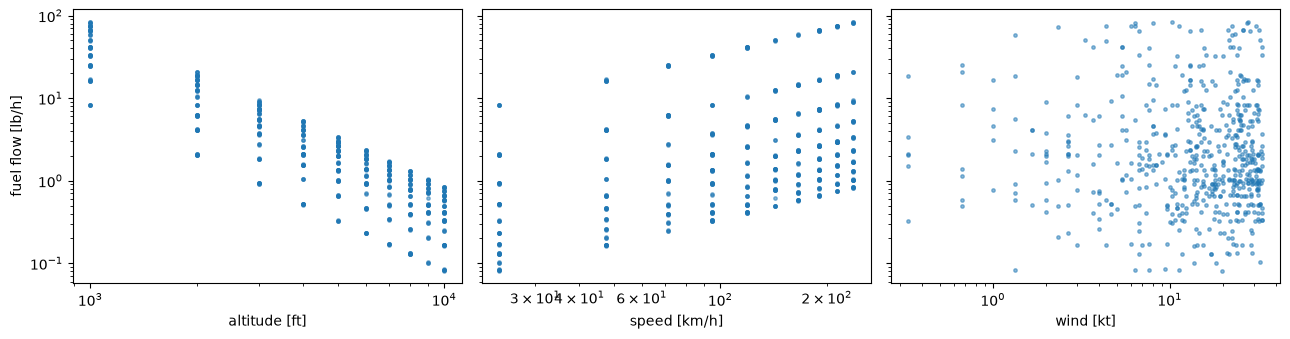

In [8]:
plot.features_vs_fuel(points)
points[cleanup.SIGNALS].transform(np.log).corr()["fuel_flow"].drop("fuel_flow").round(3)

- **Altitude**: the biggest effect. Higher means much less fuel.
- **Speed**: second. It is why the altitude plot fans out.
- **Wind**: no visible pattern. It is still tested in each model below.

**Q1 answer: processing steps**
1. Turn the values into numbers and stack all flights into one table.
2. Remove empty cells.
3. Remove the 3 faulty flights (7, 12, 44).
4. Remove spikes: physically impossible values.
5. Keep one row per step, so a long step doesn't count more than a short one.
6. Use speed and altitude, on a log scale, as features. Test wind as a candidate.

## Q2: Fuel vs speed, at 8000 ft

In [9]:
q2 = points[points.altitude == 8000]
k2, b2 = compute.fit([q2.speed], q2.fuel_flow)
res2 = q2.fuel_flow - (k2 * q2.speed + b2)
print(f"speed range {q2.speed.min()}-{q2.speed.max()} km/h, n={len(q2)}")
print(f"ff = {k2:.5f} * v + {b2:.5f}   R2={compute.r2(q2.fuel_flow, q2.fuel_flow - res2):.5f}")

speed range 23.75-237.5 km/h, n=54
ff = 0.00547 * v + -0.00012   R2=0.99952


A straight line through zero fits almost perfectly: **double the speed, double the fuel**.

**Wind:** adding it to the regression tests whether it improves the fit.

wind coef -4.03e-05 lb/h per kt -> -0.19% of mean ff over 0-33 kt
residual std: without wind 0.0085, with wind 0.0085


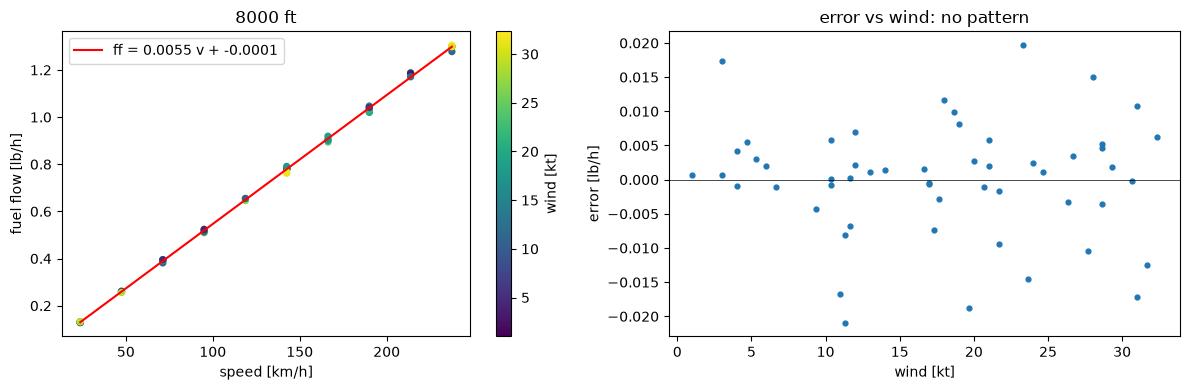

In [10]:
beta_w = compute.fit([q2.speed, q2.wind], q2.fuel_flow)
res2w = q2.fuel_flow - compute.design([q2.speed, q2.wind]) @ beta_w
w2 = beta_w[1] / q2.fuel_flow.mean()
print(f"wind coef {beta_w[1]:.2e} lb/h per kt -> {w2 * 33:+.2%} of mean ff over 0-33 kt")
print(f"residual std: without wind {res2.std():.4f}, with wind {res2w.std():.4f}")
plot.speed_fit(q2, k2, b2, res2);

**Q2 answer:** at 8000 ft, fuel ≈ 0.0055 × speed, from 24 to 238 km/h. The line explains
99.95% of the variation (R²). Wind changes fuel by less than 0.2%, so it is left out.

## Q3: Fuel vs altitude, at 166.25 km/h

In [11]:
q3 = points[points.speed == 166.25]
k3, b3 = compute.fit([q3.altitude], q3.fuel_flow)
print(f"n={len(q3)}, altitude range {q3.altitude.min():.0f}-{q3.altitude.max():.0f} ft")
print(f"dead end, linear in h: R2={compute.r2(q3.fuel_flow, k3 * q3.altitude + b3):.3f}")

n=51, altitude range 1000-10000 ft
dead end, linear in h: R2=0.396


**Dead end:** a straight line does not fit (R² = 0.4). Fuel drops fast at first,
then slowly. On log scales this curve becomes a straight line, so the fit is done there.

In [12]:
c3, a3 = compute.fit([np.log(q3.altitude)], np.log(q3.fuel_flow))
pred3 = np.exp(a3) * q3.altitude**c3
max_err = np.max(np.abs(q3.fuel_flow / pred3 - 1))
print(f"log ff = {a3:.3f} + {c3:.4f} log h  ->  ff = {np.exp(a3):.4g} * h^{c3:.3f}")
print(f"R2 (ff scale) {compute.r2(q3.fuel_flow, pred3):.5f}, max relative error {max_err:.2%}")
res3 = np.log(q3.fuel_flow / pred3)
cw = compute.fit([np.log(q3.altitude), q3.wind], np.log(q3.fuel_flow))[1]
print(f"wind coef in log model {cw:.2e} per kt -> {np.expm1(cw * 33):+.2%} over 0-33 kt")

log ff = 17.910 + -2.0037 log h  ->  ff = 6.002e+07 * h^-2.004
R2 (ff scale) 0.99993, max relative error 2.07%
wind coef in log model -1.13e-04 per kt -> -0.37% over 0-33 kt


500      234.585
1000      58.495
5000       2.326
10000      0.580
12500      0.371
15000      0.257
Name: ff [lb/h], dtype: float64

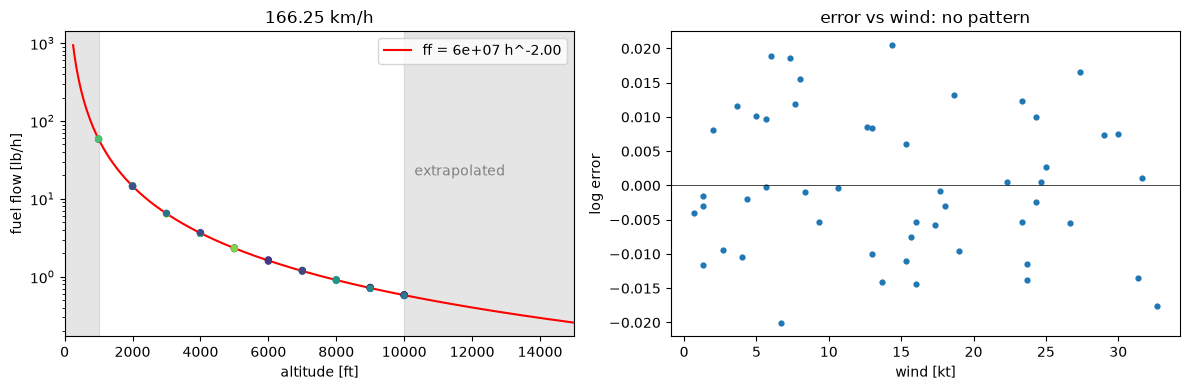

In [13]:
plot.altitude_fit(q3, np.exp(a3), c3, res3)
pd.Series(
    {alt: np.exp(a3) * alt**c3 for alt in [500, 1_000, 5_000, 10_000, 12_500, 15_000]},
    name="ff [lb/h]",
).round(3)

**Q3 answer:** fuel ≈ 60 000 000 ÷ altitude². Double the height, a quarter of the fuel. The
largest error is 2%.
- The data covers 1000 to 10 000 ft only. Grey zones are extrapolation.
- Above 10 000 ft the curve is smooth, so extrapolating to 15 000 ft is reasonable but unverified.
- Below 1000 ft the rule grows without limit towards the ground, which is not physical. It
  should not be used there.
- Wind: no effect here either.

## Q4: Fuel vs speed and altitude together

Validation: 20% of the flights are held out, the rule is fitted on the rest, then checked on the
held-out flights.

In [14]:
train, test = compute.split_by_flight(points)
x_train = [np.log(train.speed), np.log(train.altitude)]
x_test = [np.log(test.speed), np.log(test.altitude)]
candidates = {
    "speed, altitude": (x_train, x_test),
    "+ wind": ([*x_train, train.wind], [*x_test, test.wind]),
}
for name, (xtr, xte) in candidates.items():
    beta = compute.fit(xtr, np.log(train.fuel_flow))
    pred = np.exp(compute.design(xte) @ beta)
    test_r2 = compute.r2(test.fuel_flow, pred)
    mape = np.mean(np.abs(pred / test.fuel_flow - 1))
    print(f"{name:16} coefs={np.round(beta, 5)}  test R2={test_r2:.5f}  MAPE={mape:.2%}")

speed, altitude  coefs=[ 0.99981 -1.99903 12.75644]  test R2=0.99985  MAPE=0.97%
+ wind           coefs=[ 0.99981 -1.99903 -0.      12.75648]  test R2=0.99985  MAPE=0.97%


On flights it never saw, the rule is off by only 1% on average. Adding wind gives the same
score. The final rule therefore uses speed and altitude, fitted on all flights.

In [15]:
b_v, b_h, a = compute.fit([np.log(points.speed), np.log(points.altitude)], np.log(points.fuel_flow))
C = np.exp(a)
print(f"ff = {C:.4g} * v^{b_v:.4f} * h^{b_h:.4f}")

comparison = pd.DataFrame(
    {
        "slice fit": [k2, np.exp(a3) * 1_000**c3, np.exp(a3) * 10_000**c3, c3],
        "Q4 model": [
            C * 8_000**b_h,
            C * 166.25**b_v * 1_000**b_h,
            C * 166.25**b_v * 10_000**b_h,
            b_h,
        ],
    },
    index=[
        "Q2 slope ff/v @ 8000 ft",
        "Q3 ff @ 166.25 km/h, 1000 ft",
        "Q3 ff @ 166.25 km/h, 10000 ft",
        "Q3 altitude exponent",
    ],
)
comparison["rel diff"] = (comparison["Q4 model"] / comparison["slice fit"] - 1).map(
    "{:+.2%}".format
)
comparison

ff = 3.466e+05 * v^1.0001 * h^-1.9991


,slice fit,Q4 model,rel diff
Q2 slope ff/v @ 8000 ft,0.005469,0.005459,-0.17%
"Q3 ff @ 166.25 km/h, 1000 ft",58.494828,58.007577,-0.83%
"Q3 ff @ 166.25 km/h, 10000 ft",0.579945,0.581254,+0.23%
Q3 altitude exponent,-2.003731,-1.999119,-0.23%


The Q2 and Q3 rules agree with this one within 1%: it is the same rule, seen from two sides.

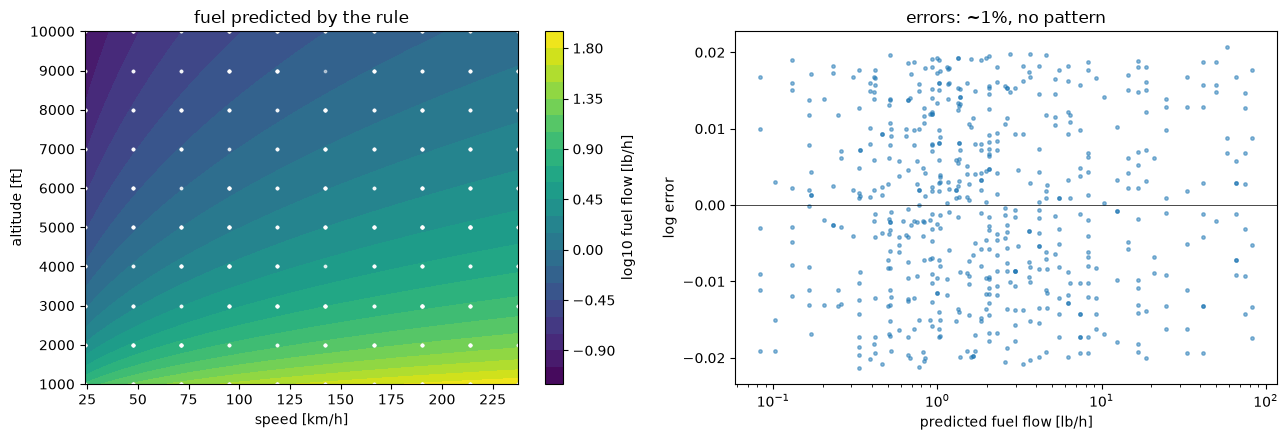

In [16]:
plot.model_map(points, C, b_v, b_h);

**Q4 answer:**

$$\text{fuel} \approx 346\,600 \times \frac{\text{speed}}{\text{altitude}^2}$$

for 24-238 km/h and 1000-10 000 ft. Errors (right plot) are about 1%, with no pattern.
Wind is left out.

### Dead end: repairing the faulty flights
The rule can be inverted: from fuel and altitude it gives speed, and vice versa. This was checked
on the faulty flights but not used for training, since learning a rule from data corrected by that
same rule is circular.

In [17]:
broken = samples[samples.flight.isin([7, 44])].drop_duplicates(["flight", *cleanup.SIGNALS])
f7 = broken[broken.flight == 7].set_index("t")
f44 = broken[broken.flight == 44].set_index("t")
pd.concat(
    {
        "flight 7: model speed minus recorded": (f7.fuel_flow / (C * f7.altitude**b_h)) ** (1 / b_v)
        - f7.speed,
        "flight 44: model altitude": (f44.fuel_flow / (C * f44.speed**b_v)) ** (1 / b_h),
    }
).round(0).rename("value")

                                      t 
flight 7: model speed minus recorded  0     -197.0
                                      2     -199.0
                                      4     -201.0
                                      8     -200.0
                                      10    -198.0
                                      15    -201.0
flight 44: model altitude             0     1008.0
                                      4     2000.0
                                      7     1008.0
                                      10    5019.0
                                      15    1003.0
                                      17    8077.0
Name: value, dtype: float64

- **Flight 7**: the rule puts the true speed about 200 km/h below the recorded one: a constant
  sensor offset.
- **Flight 44**: the rule puts it at 1000-8000 ft, like the other flights: the altitude sensor
  is faulty.

## Limitations
- The flights are simulated. Real aircraft burn thousands of pounds per hour, not 0.08-84, so
  the units may differ. The rule is unaffected.
- The rule is validated only within the data range: 24-238 km/h and 1000-10 000 ft.
- Wind likely has no effect because `speed` is airspeed. Wind changes speed over the ground, not
  the engine's workload.